
---

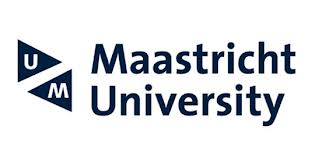


# Faculty of Science and Engineering — Department of Advanced Computing Sciences

# ANLP 2026-2027 — Assignment 1: NLP Fundamentals

**Covers:** Tutorials 01 (Tokenization), 02 (Document Representation), 03 (Measuring Quality), 04 (Syntax & Semantics), 05 (Statistical NLP)

⏱️ **Estimated time:** 1.2 hours – 2.5 hours

By Jan Scholtes — Version 2026-2027

---

**Instructions:**
- This is a **graded assignment** worth 80 points
- You will analyse a set of product reviews using a complete NLP pipeline
- Each exercise builds on concepts from multiple tutorials
- Fill in the `# TODO` sections and write your answers where indicated
- Do **not** modify test cells

**Time estimate:** ~4-5 hours

## Dataset: Product Reviews

In [ ]:
import nltk
import numpy as np
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('treebank', quiet=True)

# Dataset: 20 product reviews with sentiment labels (1 = positive, 0 = negative)
reviews = [
    "This laptop is absolutely fantastic, the battery lasts forever and the screen is beautiful.",
    "Terrible product. Broke after two weeks of normal use. Complete waste of money.",
    "Great value for the price. Not perfect, but does everything I need it to do.",
    "The worst headphones I've ever owned. Awful sound quality and uncomfortable fit.",
    "I love this camera! The image quality is stunning and it's very easy to use.",
    "Don't buy this. The software crashes constantly and customer support is useless.",
    "Excellent build quality and the performance exceeded my expectations. Highly recommend!",
    "Returned it immediately. The product looked nothing like the pictures online.",
    "Perfect gift for my daughter. She uses it every day and hasn't had any issues.",
    "Disappointing purchase. The features advertised are misleading and barely functional.",
    "Amazing sound quality and noise cancellation. Best purchase I've made this year!",
    "Cheaply made garbage. The buttons stopped working after a month of light use.",
    "Very impressed with the design and functionality. Works exactly as described.",
    "Save your money. This is an overpriced piece of junk with zero reliability.",
    "Comfortable, lightweight, and great battery life. Perfect for travel and commuting.",
    "The screen broke on day three. Absolutely unacceptable for a product at this price.",
    "Solid performance and excellent customer service when I had a question. Five stars!",
    "Honestly the worst tech purchase I've ever made. Nothing works as advertised.",
    "Super happy with this purchase. Fast shipping and the product works flawlessly.",
    "Complete disaster. Overheats constantly, freezes randomly, and the manual is incomprehensible."
]

sentiments = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

print(f"Loaded {len(reviews)} reviews ({sum(sentiments)} positive, {len(sentiments)-sum(sentiments)} negative)")

# Exercises

## Exercise A1: Preprocessing Pipeline (20 points)

*Integrates: Tutorial 01 (Tokenization) + Tutorial 04 (Syntax & Semantics)*

**a)** (10 points — code) Complete the `preprocess_review` function below. It should:
1. Tokenize the text using NLTK `word_tokenize`
2. POS-tag the tokens using `nltk.pos_tag`
3. Lemmatize each token using `WordNetLemmatizer` (use the helper `get_wordnet_pos` to convert POS tags)
4. Return a dictionary with keys `"tokens"`, `"pos_tags"` (list of `(word, tag)` tuples), and `"lemmas"`

Then apply it to all reviews and store the results in `processed_reviews`.

**b)** (10 points — explanation) Compare word-level tokenization (NLTK) with subword tokenization (BERT's WordPiece). When does subword tokenization help? Give a concrete example from the reviews.

In [ ]:
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

def get_wordnet_pos(treebank_tag):
    """Convert POS tag to WordNet POS for better lemmatization."""
    if treebank_tag.startswith('J'): return wordnet.ADJ
    elif treebank_tag.startswith('V'): return wordnet.VERB
    elif treebank_tag.startswith('N'): return wordnet.NOUN
    elif treebank_tag.startswith('R'): return wordnet.ADV
    else: return wordnet.NOUN

def preprocess_review(text):
    """Tokenize, POS-tag, and lemmatize a review."""
    lemmatizer = WordNetLemmatizer()
    # TODO: tokenize with word_tokenize
    # TODO: POS-tag with nltk.pos_tag
    # TODO: lemmatize each token using get_wordnet_pos for the POS argument
    # TODO: return dict with "tokens", "pos_tags", "lemmas"
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

processed_reviews = [preprocess_review(r) for r in reviews]

# Show example
ex = processed_reviews[0]
print(f"Original:  {reviews[0]}")
print(f"Tokens:    {ex['tokens'][:10]}...")
print(f"POS tags:  {ex['pos_tags'][:10]}...")
print(f"Lemmas:    {ex['lemmas'][:10]}...")

In [ ]:
# AUTO-GRADED TESTS (10 points)
# Do not modify this cell



### A1 Explanation (10 points — manually graded)

Compare word-level (NLTK) vs. subword (BERT WordPiece) tokenization. Answer the following:

1. How do their vocabulary sizes compare?
2. How does each approach handle out-of-vocabulary (OOV) words?
3. What is the difference in token granularity?
4. When is each approach best suited?
5. Give a concrete example from the reviews where subword tokenization helps (2-3 sentences).

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A2: Document Representation & Retrieval (20 points)

*Integrates: Tutorial 02 (Document Representation) + Tutorial 01 (Tokenization)*

**a)** (10 points — code) Complete the code below to:
1. Build a TF-IDF matrix from the **lemmatized** reviews (join lemmas with spaces)
2. Implement `find_similar(query, k=3)` that returns the top-k most similar reviews as a list of `(similarity_score, review_index)` tuples, sorted by score descending

**b)** (10 points — explanation) Why does TF-IDF work well for this retrieval task? When would dense embeddings (Word2Vec, SBERT) be a better choice?

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Build TF-IDF from lemmatized reviews
lemma_docs = [" ".join(pr["lemmas"]) for pr in processed_reviews]
vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform(lemma_docs)

def find_similar(query, k=3):
    """Find the k most similar reviews to a query string.
    Returns list of (similarity_score, review_index) sorted descending."""
    # TODO: transform the query using the fitted vectorizer
    # TODO: compute cosine similarity between query and all reviews
    # TODO: get top-k indices (sorted by similarity descending)
    # TODO: return list of (float(score), int(index)) tuples
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

# Test
results = find_similar("great battery life for travel")
print("Query: 'great battery life for travel'")
for score, idx in results:
    print(f"  sim={score:.4f}: {reviews[idx][:80]}...")

In [ ]:
# AUTO-GRADED TESTS (10 points)
# Do not modify this cell



### A2 Explanation (10 points — manually graded)

Why does TF-IDF work well for this retrieval task, and when would dense embeddings be better? Answer the following:

1. What does TF-IDF capture vs. what do dense embeddings (SBERT) capture?
2. What are the strengths of TF-IDF for this specific task?
3. What are the weaknesses of each approach?
4. When would you prefer TF-IDF, and when would you prefer dense embeddings?

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A3: Evaluation Metrics (20 points)

*Integrates: Tutorial 03 (Measuring Quality) + Tutorial 02 (Document Representation)*

**a)** (12 points — code) A simple TF-IDF sentiment classifier has been trained for you. Complete the `compute_metrics` function that calculates precision, recall, and F1 **from scratch** (no sklearn). Then compare your results with sklearn's metrics.

**b)** (8 points — explanation) Interpret the results: which class is harder to classify and why?

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Train a simple sentiment classifier (given — do not modify)
X_train, X_test, y_train, y_test = train_test_split(
    tfidf_matrix, sentiments, test_size=0.3, random_state=42, stratify=sentiments
)
clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"Test set: {len(y_test)} reviews")
print(f"Predictions: {list(y_pred)}")
print(f"Actual:      {list(y_test)}")

In [ ]:
def compute_metrics(y_true, y_pred, positive_label=1):
    """Compute precision, recall, and F1 from scratch.
    Returns dict with keys 'precision', 'recall', 'f1'."""
    # TODO: count true positives (TP), false positives (FP), false negatives (FN)
    # TODO: compute precision = TP / (TP + FP)
    # TODO: compute recall = TP / (TP + FN)
    # TODO: compute f1 = 2 * precision * recall / (precision + recall)
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

# Compute and display
my_metrics = compute_metrics(y_test, y_pred)
print(f"Your implementation:  P={my_metrics['precision']:.4f}  R={my_metrics['recall']:.4f}  F1={my_metrics['f1']:.4f}")

# Compare with sklearn
sk_p = precision_score(y_test, y_pred)
sk_r = recall_score(y_test, y_pred)
sk_f = f1_score(y_test, y_pred)
print(f"Sklearn:             P={sk_p:.4f}  R={sk_r:.4f}  F1={sk_f:.4f}")
print(f"\nConfusion matrix:\n{confusion_matrix(y_test, y_pred)}")

In [ ]:
# AUTO-GRADED TESTS (12 points)
# Do not modify this cell



### A3 Explanation (8 points — manually graded)

Look at the confusion matrix and metrics above. Answer:

1. Which class (positive/negative) has higher precision? Which has higher recall? (2 sentences)
2. Why might one class be harder to classify with TF-IDF features? (2-3 sentences)
3. Suggest one way to improve classification performance that uses knowledge from Tutorial 04 (syntax/semantics). (2 sentences)

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A4: Linguistic Analysis & Language Modeling (20 points)

*Integrates: Tutorial 04 (Syntax & Semantics) + Tutorial 05 (Statistical NLP)*

**a)** (12 points — code) Complete two tasks:

1. **Noun phrase extraction**: Complete `extract_noun_phrases(pos_tags)` that uses NLTK's `RegexpParser` with the given grammar to extract noun phrases from POS-tagged text. Return a list of NP strings.

2. **Bigram language model**: Complete `bigram_perplexity(train_tokens, test_tokens)` that builds a bigram language model (with add-1 smoothing) from `train_tokens` and computes perplexity on `test_tokens`.

**b)** (8 points — explanation) Compare the NPs extracted from positive vs. negative reviews. What patterns do you see?

In [ ]:
from nltk import RegexpParser
from collections import Counter
import math

# --- Task 1: Noun Phrase Extraction ---
np_grammar = r"NP: {<DT|PRP\$>?<JJ.*>*<NN.*>+}"
np_parser = RegexpParser(np_grammar)

def extract_noun_phrases(pos_tags):
    """Extract noun phrases from POS-tagged tokens using chunking.
    Args: pos_tags — list of (word, tag) tuples
    Returns: list of NP strings (words joined with spaces)"""
    # TODO: parse pos_tags with np_parser
    # TODO: iterate over the parse tree, find subtrees labeled 'NP'
    # TODO: for each NP subtree, join the words with spaces and collect them
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

# Extract NPs from all reviews
positive_nps = []
negative_nps = []
for i, pr in enumerate(processed_reviews):
    nps = extract_noun_phrases(pr["pos_tags"])
    if sentiments[i] == 1:
        positive_nps.extend(nps)
    else:
        negative_nps.extend(nps)

print(f"Positive NPs ({len(positive_nps)} total): {positive_nps[:8]}")
print(f"Negative NPs ({len(negative_nps)} total): {negative_nps[:8]}")

In [ ]:
# --- Task 2: Bigram Language Model with Perplexity ---

def bigram_perplexity(train_tokens, test_tokens):
    """Build a bigram LM with add-1 smoothing and compute perplexity.
    Args: train_tokens — list of tokens to train on
          test_tokens — list of tokens to evaluate
    Returns: perplexity (float)"""
    # TODO: count unigrams and bigrams in train_tokens
    # TODO: compute vocabulary size V
    # TODO: for each bigram in test_tokens, compute smoothed probability:
    #        P(w2|w1) = (count(w1,w2) + 1) / (count(w1) + V)
    # TODO: compute perplexity = exp(-1/N * sum(log(P)))
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

# Split reviews into train/test and compute perplexity
all_tokens = [t.lower() for pr in processed_reviews for t in pr["tokens"]]
split = int(len(all_tokens) * 0.8)
train_tok = all_tokens[:split]
test_tok = all_tokens[split:]

ppl = bigram_perplexity(train_tok, test_tok)
print(f"Bigram LM perplexity on held-out tokens: {ppl:.2f}")
print(f"(Train: {len(train_tok)} tokens, Test: {len(test_tok)} tokens)")

In [ ]:
# AUTO-GRADED TESTS (12 points)
# Do not modify this cell



### A4 Explanation (8 points — manually graded)

Compare the noun phrases extracted from positive vs. negative reviews:

1. List 3 NPs that are typical for positive reviews and 3 for negative reviews (from the output above).
2. What linguistic pattern distinguishes positive from negative NPs? (2-3 sentences)
3. How could you combine NP extraction with the bigram language model to build a better sentiment classifier? (2-3 sentences)

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Summary

In this assignment you built a complete NLP pipeline:

1. **Preprocessing** (T01+T04): Tokenization → POS tagging → Lemmatization
2. **Representation** (T02): TF-IDF vectors → Cosine similarity retrieval
3. **Evaluation** (T03): Precision, Recall, F1 from scratch
4. **Analysis** (T04+T05): NP chunking + Bigram language modeling with perplexity

**Total: 80 points** (44 auto-graded + 36 manually graded)